In [1]:
# =========================================
# 1. Imports
# =========================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score,
    ConfusionMatrixDisplay,
    classification_report,
    RocCurveDisplay,
    PrecisionRecallDisplay,
)

import joblib

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)
RANDOM_STATE = 42


In [2]:
# =========================================
# 2. Load dataset
# =========================================
PROCESSED_PATH = Path("../data/processed/airlines_delay_eda.csv")
RAW_PATH       = Path("../data/raw/airlines_delay.csv")

if PROCESSED_PATH.exists():
    DATA_PATH = PROCESSED_PATH
elif RAW_PATH.exists():
    DATA_PATH = RAW_PATH
else:
    raise FileNotFoundError(
        f"Dataset not found. Place airlines_delay.csv in {RAW_PATH.parent}"
    )

df = pd.read_csv(DATA_PATH)

# Fallback: if raw data loaded, recreate DepartureHour
# Time is minutes since midnight (0=00:00, 1439=23:59)
if "DepartureHour" not in df.columns and "Time" in df.columns:
    df["DepartureHour"] = df["Time"] // 60

# Drop non-feature columns
drop_cols = ["id", "Flight", "Time", "DepartureMinute", "IsWeekend", "LengthBin", "Route"]
df = df.drop(columns=[c for c in drop_cols if c in df.columns])

print("Source :", DATA_PATH)
print("Shape  :", df.shape)
print("Columns:", df.columns.tolist())
display(df.head())


Source : ..\data\processed\airlines_delay_eda.csv
Shape  : (539383, 7)
Columns: ['Airline', 'AirportFrom', 'AirportTo', 'DayOfWeek', 'Length', 'DepartureHour', 'Delay']


,Airline,AirportFrom,AirportTo,DayOfWeek,Length,DepartureHour,Delay
0,CO,SFO,IAH,3,205,0,1
1,US,PHX,CLT,3,222,0,1
2,AA,LAX,DFW,3,165,0,1
3,AA,SFO,DFW,3,195,0,1
4,AS,ANC,SEA,3,202,0,0


In [3]:
# =========================================
# 3. Define features and target
# =========================================
TARGET = "Delay"

X = df.drop(columns=[TARGET])
y = df[TARGET]

print("Features:", X.columns.tolist())
print("X shape :", X.shape)
print()
dist = y.value_counts(normalize=True).mul(100).round(1).rename("% share")
print("Target distribution:")
display(dist)
# Majority class accuracy is the floor our model must beat
majority_acc = dist.max() / 100
print(f"\nMajority class accuracy (floor to beat): {majority_acc:.2%}")


Features: ['Airline', 'AirportFrom', 'AirportTo', 'DayOfWeek', 'Length', 'DepartureHour']
X shape : (539383, 6)

Target distribution:


Delay
0    55.5
1    44.5
Name: % share, dtype: float64


Majority class accuracy (floor to beat): 55.50%


In [4]:
# =========================================
# 4. Feature types
# =========================================
# DayOfWeek: categorical (no meaningful linear order for delay risk)
# IsWeekend: excluded — redundant with DayOfWeek
CATEGORICAL = ["Airline", "AirportFrom", "AirportTo", "DayOfWeek"]
NUMERIC     = ["Length", "DepartureHour"]

assert all(f in X.columns for f in CATEGORICAL + NUMERIC), \
    "Feature mismatch — check processed CSV."

print("Categorical:", CATEGORICAL)
print("Numeric    :", NUMERIC)


Categorical: ['Airline', 'AirportFrom', 'AirportTo', 'DayOfWeek']
Numeric    : ['Length', 'DepartureHour']


In [5]:
# =========================================
# 5. Train / test split
# =========================================
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y,          # preserve class ratio in both splits
)

print(f"Train: {X_train.shape}  |  delay rate: {y_train.mean():.3f}")
print(f"Test : {X_test.shape}   |  delay rate: {y_test.mean():.3f}")


Train: (431506, 6)  |  delay rate: 0.445
Test : (107877, 6)   |  delay rate: 0.445


In [6]:
# =========================================
# 6. Preprocessing pipeline
# =========================================
# No imputer needed: EDA confirmed zero missing values.
# OHE note: AirportFrom + AirportTo produce ~586 sparse columns.
# handle_unknown='ignore' zeroes out unseen airports at inference time.

preprocessor = ColumnTransformer([
    ("num", StandardScaler(), NUMERIC),
    ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), CATEGORICAL),
], remainder="drop")


In [7]:
# =========================================
# 7. Naive baseline — DummyClassifier
# =========================================
# A DummyClassifier (majority class) sets the absolute performance floor.
# Any real model must clearly beat this to be useful.

dummy = DummyClassifier(strategy="most_frequent", random_state=RANDOM_STATE)
dummy.fit(X_train, y_train)

y_pred_dummy  = dummy.predict(X_test)
y_proba_dummy = dummy.predict_proba(X_test)[:, 1]

dummy_metrics = {
    "Accuracy" : accuracy_score(y_test, y_pred_dummy),
    "Precision": precision_score(y_test, y_pred_dummy, zero_division=0),
    "Recall"   : recall_score(y_test, y_pred_dummy, zero_division=0),
    "F1"       : f1_score(y_test, y_pred_dummy, zero_division=0),
    "ROC-AUC"  : roc_auc_score(y_test, y_proba_dummy),
}

print("DummyClassifier (majority class):")
for k, v in dummy_metrics.items():
    print(f"  {k:<10}: {v:.4f}")


DummyClassifier (majority class):
  Accuracy  : 0.5546
  Precision : 0.0000
  Recall    : 0.0000
  F1        : 0.0000
  ROC-AUC   : 0.5000


In [8]:
# =========================================
# 8. Logistic Regression pipeline
# =========================================
# Logistic Regression: fast, interpretable, coefficients are inspectable.
# class_weight=None: 55/45 split is mild — default is fine for baseline.

lr_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier",   LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)),
])

lr_pipeline.fit(X_train, y_train)
print("Logistic Regression trained.")


Logistic Regression trained.


In [9]:
# =========================================
# 9. Evaluate and compare
# =========================================
y_pred_lr  = lr_pipeline.predict(X_test)
y_proba_lr = lr_pipeline.predict_proba(X_test)[:, 1]

lr_metrics = {
    "Accuracy" : accuracy_score(y_test, y_pred_lr),
    "Precision": precision_score(y_test, y_pred_lr, zero_division=0),
    "Recall"   : recall_score(y_test, y_pred_lr, zero_division=0),
    "F1"       : f1_score(y_test, y_pred_lr, zero_division=0),
    "ROC-AUC"  : roc_auc_score(y_test, y_proba_lr),
}

# Side-by-side comparison
comparison_df = pd.DataFrame({
    "Metric" : list(lr_metrics.keys()),
    "Dummy"  : list(dummy_metrics.values()),
    "LR"     : list(lr_metrics.values()),
})
comparison_df["Delta"] = comparison_df["LR"] - comparison_df["Dummy"]
display(comparison_df.round(4))

print()
print(classification_report(y_test, y_pred_lr, target_names=["No Delay", "Delay"], zero_division=0))


,Metric,Dummy,LR,Delta
0,Accuracy,0.5546,0.6464,0.0918
1,Precision,0.0000,0.6345,0.6345
2,Recall,0.0000,0.4862,0.4862
3,F1,0.0000,0.5506,0.5506
4,ROC-AUC,0.5000,0.6921,0.1921



              precision    recall  f1-score   support

    No Delay       0.65      0.78      0.71     59824
       Delay       0.63      0.49      0.55     48053

    accuracy                           0.65    107877
   macro avg       0.64      0.63      0.63    107877
weighted avg       0.64      0.65      0.64    107877



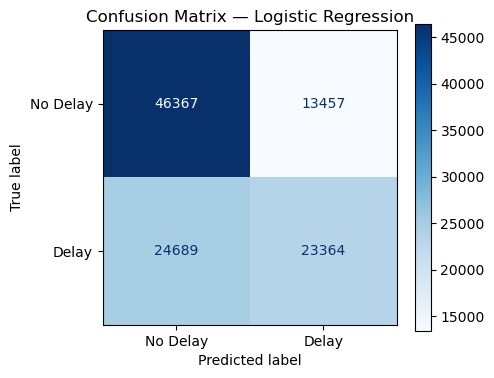

In [10]:
# =========================================
# 10. Confusion matrix
# =========================================
fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_lr,
    display_labels=["No Delay", "Delay"],
    cmap="Blues",
    ax=ax,
)
ax.set_title("Confusion Matrix — Logistic Regression")
plt.tight_layout()
plt.show()


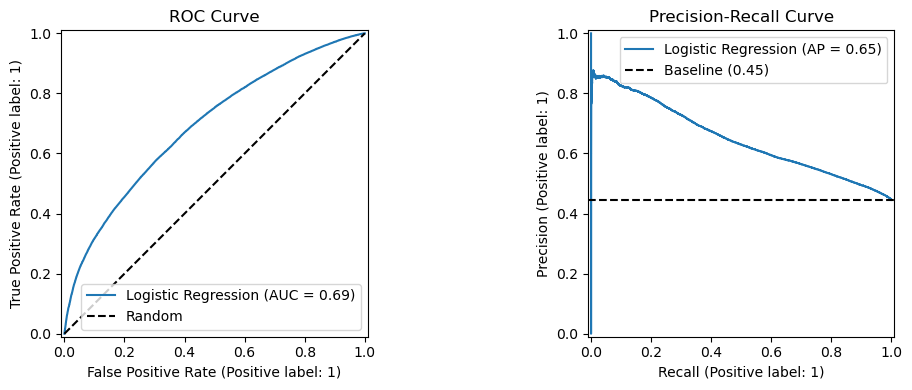

In [11]:
# =========================================
# 11. ROC curve and Precision-Recall curve
# =========================================
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))

RocCurveDisplay.from_predictions(y_test, y_proba_lr, ax=ax1, name="Logistic Regression")
ax1.plot([0, 1], [0, 1], "k--", label="Random")
ax1.set_title("ROC Curve")
ax1.legend()

PrecisionRecallDisplay.from_predictions(y_test, y_proba_lr, ax=ax2, name="Logistic Regression")
ax2.axhline(y_test.mean(), color="k", linestyle="--", label=f"Baseline ({y_test.mean():.2f})")
ax2.set_title("Precision-Recall Curve")
ax2.legend()

plt.tight_layout()
plt.show()


Top 20 most influential features:


,Feature,Coefficient
0,Airline_WN,1.378455
1,AirportTo_OME,0.900691
2,AirportFrom_ECP,-0.864737
3,AirportFrom_ORD,0.864003
4,AirportFrom_HRL,-0.852067
5,AirportTo_JAC,0.781684
6,AirportTo_LSE,-0.776932
7,AirportTo_SJU,0.775549
8,AirportFrom_LFT,-0.768144
9,AirportFrom_KOA,-0.750649


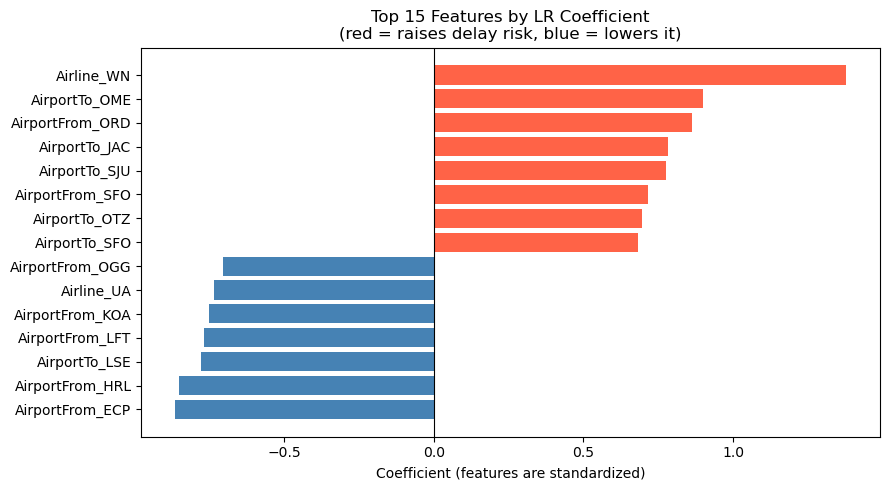

In [12]:
# =========================================
# 12. Feature importance (LR coefficients)
# =========================================
# In Logistic Regression, the coefficient of each feature shows its contribution
# to the log-odds of a delay. Features are scaled, so coefficients are comparable.
# Positive = increases delay probability. Negative = decreases it.

ohe_names = (
    lr_pipeline.named_steps["preprocessor"]
    .named_transformers_["cat"]
    .get_feature_names_out(CATEGORICAL)
    .tolist()
)
feature_names = NUMERIC + ohe_names
coefs = lr_pipeline.named_steps["classifier"].coef_[0]

coef_df = (
    pd.DataFrame({"Feature": feature_names, "Coefficient": coefs})
    .assign(AbsCoef=lambda d: d["Coefficient"].abs())
    .sort_values("AbsCoef", ascending=False)
    .reset_index(drop=True)
)

print("Top 20 most influential features:")
display(coef_df[["Feature", "Coefficient"]].head(20))

# Bar chart — top 15
top15 = coef_df.head(15).sort_values("Coefficient")
colors = ["tomato" if c > 0 else "steelblue" for c in top15["Coefficient"]]

plt.figure(figsize=(9, 5))
plt.barh(top15["Feature"], top15["Coefficient"], color=colors)
plt.axvline(0, color="black", linewidth=0.8)
plt.title("Top 15 Features by LR Coefficient\n(red = raises delay risk, blue = lowers it)")
plt.xlabel("Coefficient (features are standardized)")
plt.tight_layout()
plt.show()


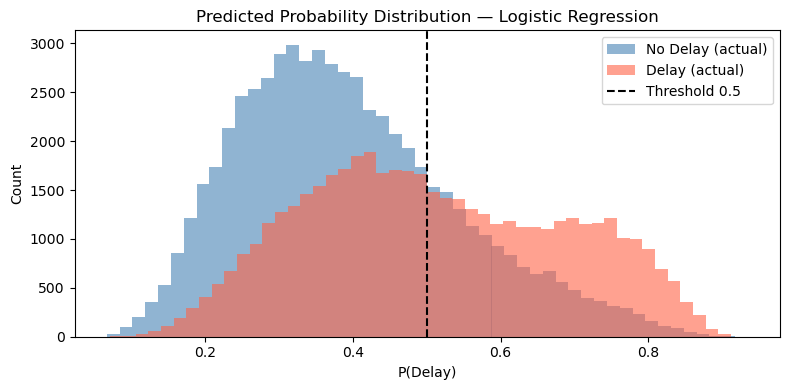

In [13]:
# =========================================
# 13. Predicted probability distribution
# =========================================
# A well-calibrated model pushes probabilities toward 0 and 1.
# If both classes cluster around 0.5, the model is uncertain — a sign
# that a more powerful model (e.g. Random Forest) may help.

plt.figure(figsize=(8, 4))
plt.hist(y_proba_lr[y_test == 0], bins=50, alpha=0.6,
         label="No Delay (actual)", color="steelblue")
plt.hist(y_proba_lr[y_test == 1], bins=50, alpha=0.6,
         label="Delay (actual)",    color="tomato")
plt.axvline(0.5, color="black", linestyle="--", label="Threshold 0.5")
plt.title("Predicted Probability Distribution — Logistic Regression")
plt.xlabel("P(Delay)")
plt.ylabel("Count")
plt.legend()
plt.tight_layout()
plt.show()


In [14]:
# =========================================
# 14. Save model and metrics
# =========================================
MODELS_DIR = Path("../models")
MODELS_DIR.mkdir(parents=True, exist_ok=True)

MODEL_PATH = MODELS_DIR / "baseline_model.pkl"
joblib.dump(lr_pipeline, MODEL_PATH)
print(f"Model saved   : {MODEL_PATH}")

# Save metrics for comparison in notebook 03
OUTPUT_DIR = Path("../data/processed")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

metrics_df = pd.DataFrame([
    {"model": "DummyClassifier", **dummy_metrics},
    {"model": "LogisticRegression", **lr_metrics},
])
METRICS_PATH = OUTPUT_DIR / "baseline_metrics.csv"
metrics_df.to_csv(METRICS_PATH, index=False)
print(f"Metrics saved : {METRICS_PATH}")


Model saved   : ..\models\baseline_model.pkl
Metrics saved : ..\data\processed\baseline_metrics.csv


In [15]:
# =========================================
# 15. Summary
# =========================================
print("BASELINE RESULTS")
print("=================")
print(f"Train: {X_train.shape[0]:,} rows  |  Test: {X_test.shape[0]:,} rows")
print()
print(f"{'Metric':<12} {'Dummy':>8} {'LR':>8} {'Delta':>8}")
print("-" * 40)
for _, row in comparison_df.iterrows():
    print(f"{row['Metric']:<12} {row['Dummy']:>8.4f} {row['LR']:>8.4f} {row['Delta']:>+8.4f}")
print()
print("Features:", X.columns.tolist())
print()
print("Next step: notebook 03 — compare with Random Forest / Gradient Boosting")


BASELINE RESULTS
Train: 431,506 rows  |  Test: 107,877 rows

Metric          Dummy       LR    Delta
----------------------------------------
Accuracy       0.5546   0.6464  +0.0918
Precision      0.0000   0.6345  +0.6345
Recall         0.0000   0.4862  +0.4862
F1             0.0000   0.5506  +0.5506
ROC-AUC        0.5000   0.6921  +0.1921

Features: ['Airline', 'AirportFrom', 'AirportTo', 'DayOfWeek', 'Length', 'DepartureHour']

Next step: notebook 03 — compare with Random Forest / Gradient Boosting
